# **Introduction**

---

## **Problem Statement**

To read characters in a **CAPTCHA image**, you need to apply **text recognition techniques**. The goal of this problem is to develop a system that can **accurately detect** and **extract characters from CAPTCHA images**. This is a challenging task as **CAPTCHAs** are specifically designed to be **difficult for machines** to **read** in order to **prevent automated bots** from **accessing websites**. To solve this problem, we will need to use a **combination of image processing, pattern recognition, and machine learning techniques**.

---
## **Data Structure**

The data for this **text recognition problem** is divided into **two parts**: ***Training*** and ***Validation***.

* The **training data** consists of ***856 images***, along with their corresponding **labels** which are represented by their **file names**. This data is used to train the **Deep Learning OCR model**.

* The **validation data**, on the other hand, consists of **214 images** and their respective **labels**. This data is used to **evaluate the performance** of the **model during training**, and to make sure that it **generalizes well to new data**.

By using separate **training and validation sets**, we can ensure that the **model learns to recognize characters** in the training set while **avoiding overfitting to the training data**.

---
## **Solution Framework**
As in this task we need to extract features from the image and turn them into text. For this we will need :

* CNN Network to extract image features.
* Dense network to act as a mapping between Image Embedding and the Text Model.
* RNN to convert the image encoding into text.

Although we will also need a CTC Loss. For understanding CTC I recommend you to read this blog from [towardsdatascience](https://towardsdatascience.com/intuitively-understanding-connectionist-temporal-classification-3797e43a86c)

---
## **Notebook Strcture**
This notebook is structured into **8 sections**, each focusing on different aspects of building an ***OCR (Optical Character Recognition) model***.

* **SetUp** : In this section, we **import all the necessary modules** and set **hyperparameters and constants** required for **data loading and model building**. This includes setting the batch size, learning rate, and image size.

* **Data Loading** : In this section, we load the **data into memory from the source directory**. This includes **reading the image files and their corresponding labels**. We also split the data into train and validation sets.

* **Label Preprocessing** : Since the **labels are in categorical format**, we create a dictionary to map each **unique label to a numeric value**. We also create a **reverse mapping dictionary to convert the numeric labels back to their original categorical form**.

* **Data Functions** : In this section, we create **helper functions** to **load the data** from the directories and convert the **labels to their numeric values**. We also create functions to **preprocess the images by resizing and normalizing them**.

* **Data Visualization** : Here, we take a **visual look at the data and its respective labels**. This includes plotting some sample images with their labels to understand the structure and content of the data.

* **CTC Loss** : ***CTC (Connectionist Temporal Classification)*** is a type of **loss function** used in **training OCR models**. In this section, we create a **CTC loss layer** that we will use in the **OCR model**.

* **OCR Model** : In this section, we focus on building the **OCR model**. The model architecture is based on a combination of ***convolutional neural networks (CNNs)*** and ***recurrent neural networks (RNNs)*** in an **encoder-decoder framework**. The ***CNNs*** are used for **feature extraction**, while the ***RNNs*** are used for **sequence modeling**. Finally, we train the model using the **CTC loss function** and evaluate its performance on the **validation set**.

* **Model Predictions** : In this section, we visualize the **model predictions** by plotting the **predictions** against their **true values and the respective image**.

# **Set Up**
---

Here are all the **modules used in the notebook**, and all the **constants are also defined here**.

In [2]:
# Common
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Data
from glob import glob
from tqdm import tqdm 
from tensorflow import io
import tensorflow.data as tfd

# Data Visualization
from IPython.display import clear_output as cls
import matplotlib.pyplot as plt

# Model 
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras.utils import plot_model

In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
alizahidraja_captcha_data_path = kagglehub.dataset_download('alizahidraja/captcha-data')

print('Data source import complete.')


100%|██████████| 8.72M/8.72M [00:00<00:00, 43.4MB/s]

Extracting files...


Data source import complete.


In the **data loading and model building process**, various constants are defined and used to **streamline the workflow** **and** ensure consistency in the results. Below are some of the essential constants used in the process:

* **IMG_WIDTH**: This constant defines the width of the input image and is used in the preprocessing step to resize the images.

* **IMG_HEIGHT**: This constant defines the height of the input image and is used in the preprocessing step to resize the images.

* **BATCH_SIZE**: This constant defines the number of images to be processed in a single batch during training and testing.

* **EPOCHS**: This constant defines the number of times the training data set is passed through the model during the training process.

* **LEARNING_RATE**: This constant defines the rate at which the model's weights are updated during training and affects how quickly the model learns.

* **SEED**: This constant is used to set the random seed, ensuring that the results are reproducible.

By defining these constants and using them throughout the data loading and model building process, it is possible to achieve consistent and reproducible results.

In [4]:
# Constants
BATCH_SIZE = 16

# Image Size
N_CHANNELS = 1
IMAGE_HEIGHT, IMAGE_WIDTH = [50, 200]

# The format in which the images are stored
IMAGE_FORMAT = ".png"

# The maximum number of characters in a label.
MAX_CHARS = 5

# Total number of training epochs
EPOCHS = 100

# Learning rate 
LEARNING_RATE = 1e-3

# Specify root data paths
train_path = "/kaggle/input/captcha-data/data/train/"
valid_path = "/kaggle/input/captcha-data/data/val/"

# Random Seed
SEED = 45689
np.random.seed(SEED)
tf.random.set_seed(SEED)

# **Data Loading**

---
One of the **foremost requirements** in any **machine learning project** is to **load the dataset** into memory so that we can perform **various operations on it**. In the case of **Text Recognition**, the dataset contains **images and their corresponding labels**. The dataset needs to be **preprocessed before it can be used for training the model**.

In [5]:
print(f"Train Data Size : {len(os.listdir(train_path))}")
print(f"Valid Data Size : {len(os.listdir(valid_path))}")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/captcha-data/data/train/'

In the **text recognition problem**, the data is structured in a way that **each image represents the input image and the image name represents the target label**. This makes it easy to preprocess the data and use it for training the machine learning model.

To start working with the data, the **first step** is to collect all the **file paths** for both the **training and validation data.** 

In [ ]:
# Training Paths
all_train_paths = sorted(glob(train_path + "*" + IMAGE_FORMAT))

# Validation Paths
all_valid_paths = sorted(glob(valid_path + "*" + IMAGE_FORMAT))

Before we start preprocessing the data, it is always a good idea to have a **quick look at the file paths** to ensure that they are in the **correct format** and that we have access to **all the necessary files**.

In [ ]:
print(f"Train File Paths : \n\t{all_train_paths[:5]}\n")
print(f"Valid File Paths : \n\t{all_train_paths[:5]}")

To train a **text recognition model**, we need both the **images and their corresponding labels**. We can use the **file paths** to **load the images**, but we also **need to extract the labels** from the **file paths**.

To do this, we can create a **function** that uses **string manipulation techniques** to extract the **label from the file name**. This function can then be used to **extract the labels** for all the images in the dataset.

Overall, by creating a **function** to **extract the labels** from the **file names**, we can easily load both the **images and their corresponding labels for training the text recognition model**.

In [ ]:
def extract_label(path:str) -> str:

    '''
    This function takes a single argument, which is the path of the image file, and returns the label as a string. The function works by using the
    split() method to split the path into its individual components, and then extracting the label from the resulting list. Specifically, it splits
    the path using the forward slash ('/') character as a delimiter, and then uses the second-to-last component of the resulting list as the label.
    
    The function assumes that the label is included in the file name and is separated from the rest of the name by a period ('.') character. It 
    therefore splits the file name using the period character as a delimiter, and then uses the second-to-last component of the resulting list as 
    the label.

    Argument : 
        path : The path from which the label is to be extracted.
    
    Returns :
        label : The extracted label.
    '''
    return path.split("/")[-1].split(".")[-2]

Let's see this function working.

In [ ]:
extract_label(path=all_train_paths[45])

By applying this function to all the **image paths** in the **dataset**, we can **extract all the labels needed for training the model**.

In [ ]:
# All training labels
all_train_labels = list(map(extract_label, all_train_paths))

# All validation labels
all_valid_labels = list(map(extract_label, all_valid_paths))

In [ ]:
print(f"Train File Labels : \n\t{all_train_labels[:5]}\n")
print(f"Valid File Labels : \n\t{all_valid_labels[:5]}")

# **Data Preprocessing**

---
To feed the **labels to deep learning models**, we need to convert the **string format into numerical values**. To do this, we'll create **two dictionaries**: one that maps ***categorical values to numerical values***, and another that maps those ***numerical values back to the original strings*** for inference. These mappings are crucial for building an accurate OCR model.

We'll create some **helper functions** to **load the images and encode the labels**. These functions will help us prepare our data for ***training, validation, and testing***.

* The ***load_image*** function will take an image path and return the loaded image as a NumPy array.
* The ***preprocess_label*** function will take the label and will convert it into numeric numbers.
* The ***load_dataset*** function will take an image path and label, and return the encoded image and label.

These helper functions will **streamline our data preprocessing**, making it easier to train our OCR model.

In [ ]:
def load_image(path:str):

    '''
    The load_image function loads and processes an image from a given file path using TensorFlow functions. The function takes
    in a file path as input, reads the file using the io.read_file function, and decodes the JPEG image using tf.image.decode_jpeg.
    The image is then converted to a tensor using tf.image.convert_image_dtype, resized using tf.image.resize, transposed using 
    tf.transpose, and cast to tf.float32 using tf.cast.

    The processed image is returned as output from the function, which can be used for training our text recognition model.

    Argument : 
        path : The location or the file path of the image
    
    Return : 
        image : The loaded and processed image.
    '''

    # Read file
    image = io.read_file(filename=path)

    # Decode the PNG image
    image = tf.image.decode_png(contents=image, channels=N_CHANNELS)
    
    # Convert image to a tensor
    image = tf.image.convert_image_dtype(image=image, dtype=tf.float32)

    # Resize the image
    image = tf.image.resize(images=image, size=(IMAGE_HEIGHT, IMAGE_WIDTH))

    # Transpose
    image = tf.transpose(image, perm=[1, 0, 2])

    # Cast
    image = tf.cast(image, tf.float32)
    
    return image

We need to **convert the labels**, which are **characters**, into **numerical values** for our model. To do this, we will create a **mapping** between **characters and numbers** using **String Lookup Tabel**. We will also create a **reverse mapping** that will allow us to **convert the predicted numerical values** back to **characters**.

In [ ]:
# Get the set of all unique characters : This is our character vocabulary.
characters = sorted(list(set(char for word in all_train_labels for char in word)))

# Quick look
print(f"Characters : {set(characters)}\n")
print(f"Total Number of Unique Characters : {len(characters)}")

In [ ]:
print(f"Some Images : \n\t{all_train_paths[:5]}\n")
print(f"Some Labels : {all_train_labels[:5]}\n")
max_len = max(map(len, all_train_labels))
print(f"Max Len of Label : {max_len}")

In [ ]:
# Mapping from character to numbers
char_to_num = layers.StringLookup(
    vocabulary=characters,
    mask_token=None
)

# Reverse mapping from numbers to characters.
num_to_char = layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(),
    invert=True,
    mask_token=None
)

This function will apply the **required operations** on the **labels**.

In [ ]:
def preprocess_labels(label:str) -> tf.Tensor:
    '''
    The preprocess_labels function is used to preprocess the image labels which are in string format. 
    The labels are first divided into individual characters and then each character is encoded into 
    numerical values using a predefined mapping.
    
    Arguments:
        label: A string containing the label for an image.
        
    Returns:
        label: A tensor containing the numerical representation of the label.
    '''
    
    # Split the string label into individual characters
    label = tf.strings.unicode_split(label, input_encoding='UTF-8')

    # Encode each character into its corresponding numerical value
    label = char_to_num(label)
    
    return label

In [ ]:
def load_dataset(path, label):

    # Load the image
    image = load_image(path=path)

    # Extract the label
    label = preprocess_labels(label=label)

    # return the image and label
    return {"image":image, "label":label}

Let's convert this data into **tensorflow data**.

In [ ]:
# Trainng dataset
train_ds = tfd.Dataset.from_tensor_slices((
    np.array(all_train_paths), np.array(all_train_labels)
)).shuffle(1000).repeat(2).map(load_dataset, num_parallel_calls=tfd.AUTOTUNE).batch(BATCH_SIZE).prefetch(tfd.AUTOTUNE)

# Validation dataset
valid_ds = tfd.Dataset.from_tensor_slices((
    np.array(all_valid_paths), np.array(all_valid_labels)
)).map(load_dataset, num_parallel_calls=tfd.AUTOTUNE).batch(BATCH_SIZE).prefetch(tfd.AUTOTUNE)

In [ ]:
print(f"Training Data Size   : {len(train_ds)*BATCH_SIZE}")
print(f"Validation Data Size : {len(valid_ds)*BATCH_SIZE}")

# **Data Visualization**

---
Let's have a **visual look** at the data so that we can **better understand it**. But before that, we need to create a **decoding function** that will map the labels from **Numbers to characters**.

In [ ]:
def decode_label(label):

    '''
    This function will map the label from numbers to characters, and then join them to create the final label.

    Argument : 
        label : The label to be decoded

    Return : 
        label : The decoded label
    '''

    # Reverse Mapping
    label = num_to_char(label)

    # Join the chars
    label = tf.strings.reduce_join(label).numpy().decode('utf8')

    return label

Now lets create a function for plotting the Data.

In [ ]:
def data_visualization(data, model=None, decode_fn=None, GRID=[4, 4], FIGSIZE=(20,8), cmap="binary"):

    '''
    
    This function plots a sub plot of all the images with respect to their labels, and also decode the models predictions if the model and the decode function is supplied.

    Arguments : 
        data      : The data set, which contains the images and the respective labels.
        model     : A model that will make predictions on the data.
        decode_fn : A function to decode the model predictions.
        GRID      : The 2D structure of the plots i.e. the number of rows and the number of columns.
        FIGSIZE   : The size of the plot.

    '''

    # Specify the plotting configurations
    n_rows, n_cols = GRID
    plt.figure(figsize=FIGSIZE)

    # Get the images and labels from the data
    data = next(iter(data))
    images, labels = data['image'], data['label']

    if model is not None:
        pred_labels = decode_fn(model.predict(images))

    # Iterate over the data
    for image_number, (image, label) in enumerate(zip(images, labels)):
        
        if model is not None:
            title = f"True : {decode_label(label)}\nPred : {pred_labels[image_number]}"
        else:
            title = decode_label(label)

        plt.subplot(n_rows, n_cols, image_number+1)
        plt.imshow(tf.transpose(tf.squeeze(image)), cmap=cmap)
        plt.axis('off')
        plt.title(title)
        
    # Show Plot
    cls()
    plt.show()

In [ ]:
data_visualization(data=train_ds)

Although this has nothing to do with the **original data**, but let's visualize these images with different **color maps**.

In [ ]:
data_visualization(data=train_ds, cmap='gray')

In [ ]:
data_visualization(data=train_ds, cmap='Oranges')

In [ ]:
data_visualization(data=train_ds, cmap='copper')

I personally love the **copper color map**. What about you?

# **CTC Layer**

---

The **CTC Loss/Layer** is a **crucial component** in an ***OCR model*** as it helps to calculate the **probability distribution** of different characters in an **input image sequence**, and enables the model to **recognize text** in challenging and ***variable handwriting styles.

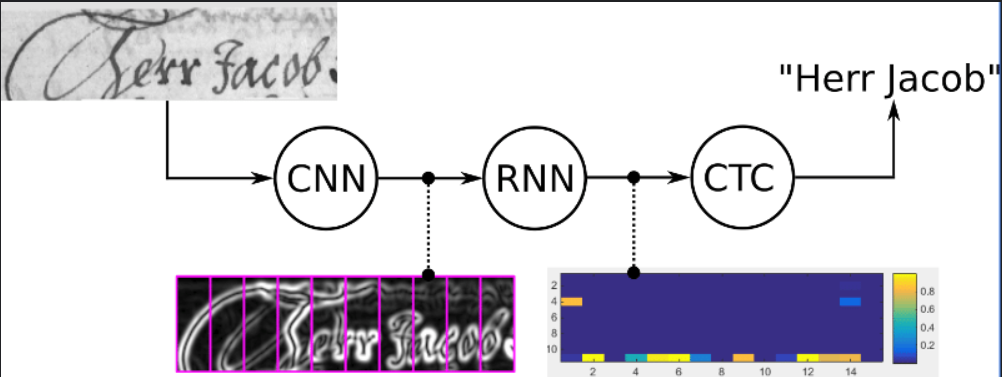

**CTC (Connectionist Temporal Classification) loss** is a loss function used in **deep learning models** for **sequence-to-sequence tasks** such as ***speech recognition, handwriting recognition, and text recognition***. The **CTC loss** is used to compute the **difference between the predicted output and the ground truth label**.

In the context of ***handwriting recognition***, the **CTC loss** takes in the **predicted sequence of characters** (in the form of **probability distribution** over the characters) and the **actual ground truth label** (which is a sequence of characters) and computes the difference between them. Since the length of the **predicted sequence** can be different from the **length of the ground truth label**, the **CTC loss** is used to align the **two sequences** by adding **blank characters** between the characters of the **predicted sequence**. This ensures that the length of the **predicted sequence matches the length of the ground truth label**.

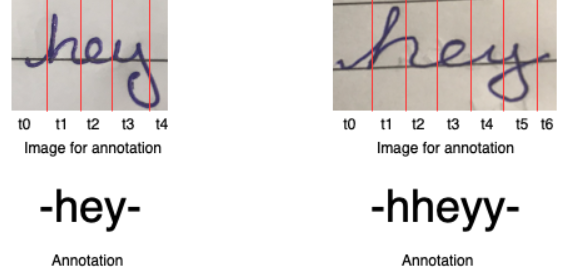

The **CTC loss** is calculated by **summing over all possible alignments** between the **predicted sequence** and the **ground truth label**. This is done by **dynamic programming**, which finds the most likely path through the **probability distribution of characters**. The **CTC loss function** then computes the **negative log probability** of the correct alignment. The goal of the **CTC loss** is to **minimize the difference between the predicted sequence and the ground truth label**.

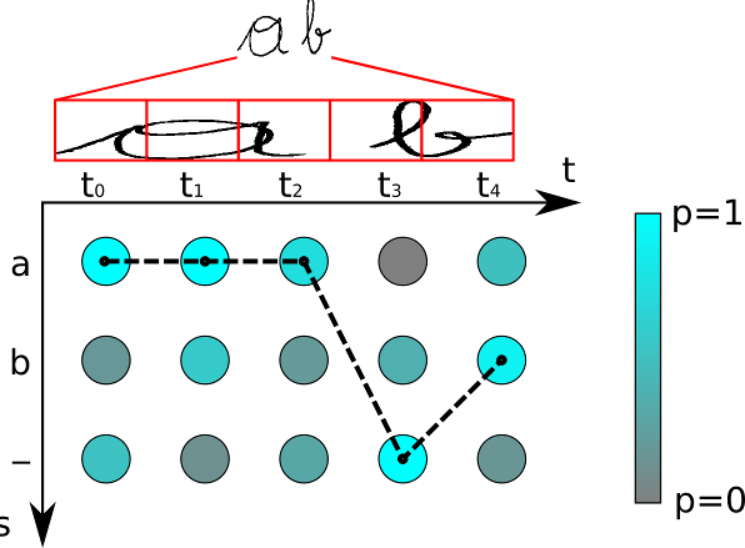

In summary, the **CTC loss** is used in ***sequence-to-sequence tasks*** to align the **predicted sequence and the ground truth label** by adding ***blank characters*** between the characters of the predicted sequence. The **CTC loss** is calculated by **dynamic programming**, and its goal is to ***minimize the difference between the predicted sequence and the ground truth label***.

In [ ]:
class CTCLayer(layers.Layer):

    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)

        self.loss_fn = keras.backend.ctc_batch_cost
    
    def call(self, y_true, y_pred):

        batch_size = tf.cast(tf.shape(y_true)[0], dtype='int64')
        input_len  = tf.cast(tf.shape(y_pred)[1], dtype='int64')
        label_len  = tf.cast(tf.shape(y_true)[1], dtype='int64')

        input_len *= tf.ones(shape=(batch_size, 1), dtype='int64')
        label_len *= tf.ones(shape=(batch_size, 1), dtype='int64')

        loss = self.loss_fn(y_true, y_pred, input_len, label_len)
        self.add_loss(loss)

        return y_pred

# **OCR Model**

---

The ***optical character recognition (OCR)*** model is a powerful combination of ***convolutional neural networks (CNNs)*** and ***recurrent neural networks (RNNs)***. The **CNNs** are used to extract **high-level features** from the input images, while the ***RNNs*** are used to **generate the corresponding text output**.

These **two types of neural networks** are combined in a **transformer-like architecture**, which can be thought of as an ***Encoder-Decoder architecture***. In this architecture, the ***CNN*** serves as the ***Encoder***, which encodes the **image features** into an **encoding space**. The ***RNN*** then acts as the ***Decoder***, which uses this **encoding space** to generate the **corresponding text output**.

The use of this architecture allows the model to handle the **challenging task of recognizing captcha text**, which is **often messy and difficult to read**. By leveraging both the **spatial information** from the ***CNNs*** and the **temporal information** from the ***RNNs***, the OCR model can **accurately recognize even the most complex handwritten text**.

Furthermore, to train the **OCR model**, a **loss function** called the ***Connectionist Temporal Classification (CTC) loss*** is used. This loss function allows the model to learn how to align the **predicted text output with the actual text output**, even in cases where there may be **missing or extra characters** in the input image. Overall, the OCR model is a powerful and effective tool for recognizing text in a wide variety of settings.

In [ ]:
# Image input layer
input_image = layers.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, N_CHANNELS), name="image", dtype=tf.float32)

# Label input layer
input_label = layers.Input(shape=(None, ), dtype=tf.float32, name="label")

# Convolutional network part for capturing the image features.
conv_1 = layers.Conv2D(
    filters=32, 
    kernel_size=3, 
    activation='relu', 
    padding='same', 
    kernel_initializer='he_normal', 
    name="Conv1"
)(input_image)

pool_1 = layers.MaxPool2D(pool_size=(2,2), name="Pool1")(conv_1)

conv_2 = layers.Conv2D(
    filters=64,
    kernel_size=3,
    activation='relu',
    padding='same',
    kernel_initializer='he_normal',
    name="Conv2"
)(pool_1)

image_embedding = layers.MaxPool2D(pool_size=(2,2), name="Pool2")(conv_2)

# Reshaped inputs carefully for making it compatible for the recurrent neural network.
reshaped = layers.Reshape(target_shape=(IMAGE_WIDTH//4, (IMAGE_HEIGHT//4)*64), name="Reshape")(image_embedding)
encoding = layers.Dense(
    64, 
    activation='relu', 
    kernel_initializer='he_normal', 
    name="DenseMapping"
)(reshaped)
encoding = layers.Dropout(0.2, name="DenseDrop")(encoding)

# Pass these representations to a recurrent neural network
rnn_1 = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(encoding)
text_embedding = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(rnn_1)

# Output layer for model predictions
output_preds = layers.Dense(units=len(char_to_num.get_vocabulary())+1, activation='softmax', name="Output")(text_embedding)

# CTC loss layer
Output = CTCLayer(name="CTCLoss")(input_label, output_preds)

In [ ]:
# Final model
ocr_model = keras.Model(
    inputs=[input_image, input_label],
    outputs=[Output]
)

# Model summary
ocr_model.summary()

**Model Visualization**
---

To gain a better understanding of the **OCR model architecture**, let's take a visual look at it. As we can see, the model is a combination of an ***encoder-decoder architecture*** and a **CTC layer** addition for training purposes. The **encoder side** of the model is comprised of a ***convolutional neural network*** that encodes the **image features into an encoding space**, while the **decoder side** is made up of a ***recurrent neural network*** that **decodes the text from the encoding space**. The **CTC layer** serves as the **connection** between the **encoder and decoder**, allowing the model to **learn and predict the sequence of characters in the text**. By visualizing the model architecture, we can better understand how it operates and how it is able to accurately recognize text from Captcha images.

In [ ]:
plot_model(model=ocr_model, to_file="OCRCaptchModel.png", show_layer_names=True, show_shapes=True, dpi=80)

# **OCR Model Training**

---
The model is ready. It's time to train it.

In [ ]:
# Compile the model
ocr_model.compile(optimizer=keras.optimizers.Adam())

# Model training
ocr_model_history = ocr_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        callbacks.ModelCheckpoint("OCRCaptchModel.h5", save_best_only=True),
    ]
)

In [ ]:
pd.DataFrame(ocr_model_history.history).plot(figsize=(10,5))
plt.title("Learning Curve", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel('CTC Loss')
plt.legend(fontsize=15)
plt.grid()
plt.show()

This is what we call a **nearly perfect training curve**. While it may appear that the **training loss diverges towards the end**, the **divergence is not significant**. Both the **training and validation loss continuously decrease**, which is a **positive sign**. This indicates that our model is able to understand the task well and is **learning to generalize well to new data**.

# **Model Prediction**

---


In order to use our trained model for **making predictions**, we need to first **remove the CTC layer** from the model. This layer was added for **training purposes only** and is **not required for making predictions**. Once we have removed this layer, we can use the remaining ***encoder-decoder network*** for prediction.

However, the **output of this network** will be a **series of numeric values**, which represent the **probabilities of each character** being present in the image. To convert these **numeric values** into the **actual characters or categorical values**, we need a ***decoding function***.

This **decoding function** takes the **output of the model** and decodes it into the **final predicted text**. There are **different decoding strategies** that can be used, such as ***greedy decoding*** or ***beam search decoding***. The specific strategy used will depend on the requirements of the task and the characteristics of the data.

Once we have the **decoding function**, we can use it to convert the **model's output into the final predicted text**, which can then be compared to the **ground truth labels** to evaluate the **performance of the model**.

In [ ]:
# We need a different model for making predictions
ocr_pred_model = keras.Model(
    inputs=ocr_model.get_layer("image").input, 
    outputs=ocr_model.get_layer('Output').output
)

# Model Summary
ocr_pred_model.summary()

In [ ]:
def decode_pred(pred_label):
    
    '''
    The decode_pred function is used to decode the predicted labels generated by the OCR model.
    It takes a matrix of predicted labels as input, where each time step represents the probability 
    for each character. The function uses CTC decoding to decode the numeric labels back into their 
    character values. The function also removes any unknown tokens and returns the decoded texts as a
    list of strings. The function utilizes the num_to_char function to map numeric values back to their
    corresponding characters. Overall, the function is an essential step in the OCR process, as it allows
    us to obtain the final text output from the model's predictions.
    
    Argument : 
        pred_label : These are the model predictions which are needed to be decoded.
        
    Return:
        filtered_text : This is the list of all the decoded and processed predictions.
    
    '''
    
    # Input length
    input_len = np.ones(shape=pred_label.shape[0]) * pred_label.shape[1]
    
    # CTC decode
    decode = keras.backend.ctc_decode(pred_label, input_length=input_len, greedy=True)[0][0][:,:MAX_CHARS]
    
    # Converting numerics back to their character values
    chars = num_to_char(decode)
    
    # Join all the characters
    texts = [tf.strings.reduce_join(inputs=char).numpy().decode('UTF-8') for char in chars]
    
    # Remove the unknown token
    filtered_texts = [text.replace('[UNK]', " ").strip() for text in texts]
    
    return filtered_texts

In [ ]:
# Get some data
data = next(iter(valid_ds))
images = data['image']
labels = data['label']

# Make Prediction
model_pred = ocr_pred_model.predict(tf.expand_dims(images[0], axis=0))

# Decode the model prediction.
print(f"Predicted Label : {decode_pred(model_pred)[0]}")

This function seems to **work perfectly fine** for **decoding the predicted labels**, but to gain better **insight and understanding**, it would be beneficial to have a **visual representation** of the **model's predictions**.

In [ ]:
data_visualization(
    data=valid_ds.shuffle(1000), 
    model=ocr_pred_model, 
    decode_fn=decode_pred, 
    cmap='copper'
)

In [ ]:
data_visualization(
    data=valid_ds.shuffle(1000), 
    model=ocr_pred_model, 
    decode_fn=decode_pred, 
    cmap='copper'
)

Based on the **Training-Validation results**, it seems like the model is **performing exceptionally well**. It is able to **accurately recognize** the text present in each **validation image** with a **low loss of only 0.2**. This indicates that the model has **successfully learned** to **generalize** from the **training data** and is able to **make accurate predictions** on **unseen data**. 

However, it is important to note that this is **only a small sample** of the data and **further evaluation** on a **larger dataset** would be **necessary to truly determine the performance of the model**. Overall, the **model's predictions** seem to be **reliable and could be used for practical applications such as text recognition in real-world scenarios**.

---
**DeepNets**